 <large><b>Assignment 10:Image Processing (FITS Files) </b></large><br>
    <b>Name: Japisher Singh Purba</b>
    <hr>
    <i></i>



In [1]:

import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt

def clean(datum):
    """
    Replace any NaN or negative pixel values by the mean
    of the valid pixels in the surrounding 3x3 neighbourhood.
    """
    for i in range(datum.shape[0]):
        for j in range(datum.shape[1]):
            if np.isnan(datum[i, j]) or datum[i, j] < 0:
                s = 0.0
                n = 0
                for x in range(i-1, i+2):
                    for y in range(j-1, j+2):
                        if x == i and y == j:
                            continue
                        try:
                            val = datum[x, y]
                            if (not np.isnan(val)) and (val >= 0):
                                s += val
                                n += 1
                        except IndexError:
                            pass
                if n > 0:
                    datum[i, j] = s / n
                else:
                    datum[i, j] = 0.0
    return datum


<hr>
    Question 1:<br>
    <i>M7 V-Mag Bubble Plots:</i>

In [2]:


df = pd.read_csv("Assignment_10_M7_Ptolemy_Star_Cluster.csv")
df


,RA(deg),Dec(deg),V-Mag
0,267.761167,-35.028889,9.90
1,267.819625,-34.820611,9.29
2,267.857083,-34.559944,9.14
3,267.853417,-34.784333,10.96
4,267.857917,-35.034389,8.75
...,...,...,...
244,268.454167,-34.818611,13.55
245,268.475833,-34.768889,12.53
246,268.540417,-34.886944,13.30
247,268.565000,-34.793889,13.32


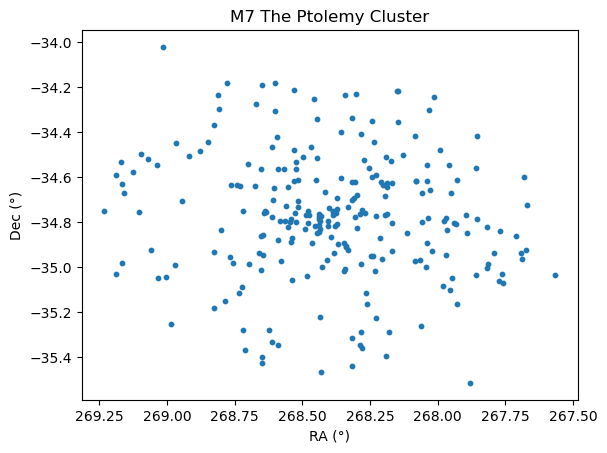

In [3]:


fig, ax = plt.subplots()
ax.scatter(df['RA(deg)'], df['Dec(deg)'], s=10)
ax.set_xlabel("RA (°)")
ax.set_ylabel("Dec (°)")
ax.set_title("M7 The Ptolemy Cluster")
ax.invert_xaxis()
plt.show()


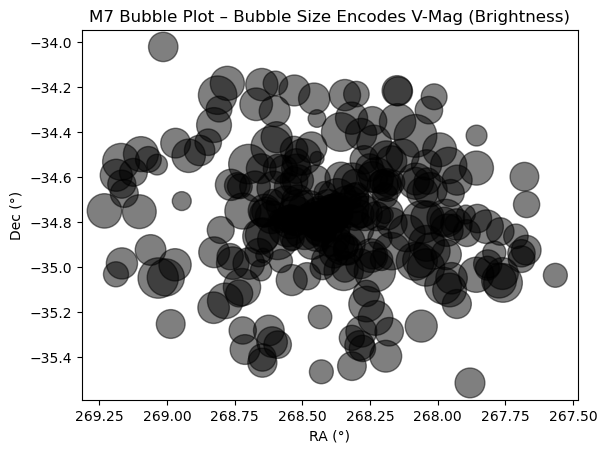

In [4]:

fig, ax = plt.subplots()

ax.invert_xaxis()

mag_scale = 100 * (df['V-Mag'].max() - df['V-Mag'] + df['V-Mag'] - df['V-Mag'].min()
                   ) / (df['V-Mag'].max())**6

mag_scale = 100 * (df['V-Mag'].max() - df['V-Mag'] + 1)

scatter = ax.scatter(
    df['RA(deg)'],
    df['Dec(deg)'],
    s=mag_scale,
    alpha=0.5,
    c='k'
)

ax.set_xlabel("RA (°)")
ax.set_ylabel("Dec (°)")
ax.set_title("M7 Bubble Plot – Bubble Size Encodes V-Mag (Brightness)")

plt.show()


<hr>
    Question 1 (b.):<br>
    <i>M7 V-Mag Bubble Plots:</i>

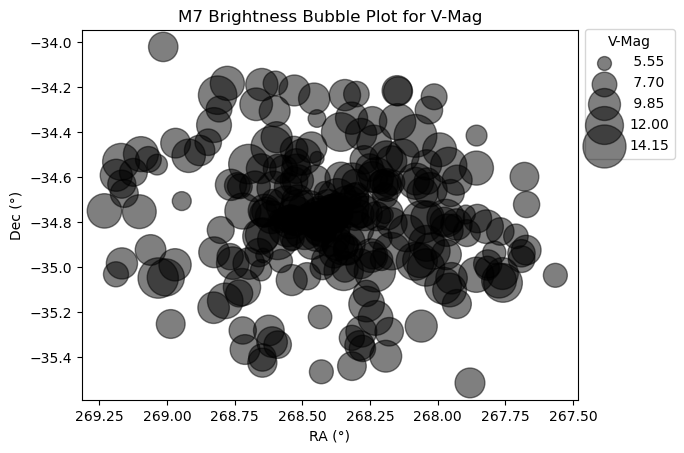

In [5]:


fig, ax = plt.subplots()
# flip RA axis

ax.invert_xaxis()

# re-use the mag_scale defined above
mag_scale = 100 * (df['V-Mag'].max() - df['V-Mag'] + 1)

# building legend
legend_handles = []# list of dummy scatter points for legend
# choose 5 representative bubble sizes between min and max
bubble_sizes = np.linspace(mag_scale.min(), mag_scale.max(), 5)

# choose 5 corresponding V-Mag values (bright → faint)
vmag_values = np.linspace(df['V-Mag'].min(), df['V-Mag'].max(), 5)
vmag_labels = [f"{m:5.2f}" for m in vmag_values]


# build the fake scatter points for legend only
for bubble_size, label in zip(bubble_sizes, vmag_labels):
    legend_handles.append(
        ax.scatter(
            [], [],# no data; just a marker for the legend            
            s=bubble_size,  # bubble size   
            c='k',# colour      
            alpha=0.5,# same transparency      
            label=label
        )
    )
# actual M7 brightness bubble plot
ax.scatter(
    df['RA(deg)'],     # x-values: RA       
    df['Dec(deg)'],      # y-values: Dec      
    s=mag_scale,           # bubble size encoding brightness   
    alpha=0.5,
    c='k'
)
# legend
ax.legend(
    handles=legend_handles,  # use our dummy scatter points
    labels=vmag_labels,       # show the chosen V-Mag values 
    title="V-Mag",          # legend title
    loc="upper left",
    bbox_to_anchor=(1, 1.0225)
)

ax.set_xlabel("RA (°)")
ax.set_ylabel("Dec (°)")
ax.set_title("M7 Brightness Bubble Plot for V-Mag")

plt.show()


<hr>
    Question 2:<br>
    <i>Exploring FITS Files:</i>

<hr>
    Question 2a.:<br>

In [6]:

image_file = "native_res_11_12_arcsec_s12.0arcmin.fits"
hdu_list = fits.open(image_file)
hdu_list.info()


Filename: native_res_11_12_arcsec_s12.0arcmin.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      66   (360, 360, 1, 1)   float32   


<hr>
    Question 2b:<br>

In [7]:
image_header = hdu_list[0].header
image_header


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    4 / number of array dimensions                     
NAXIS1  =                  360                                                  
NAXIS2  =                  360                                                  
NAXIS3  =                    1                                                  
NAXIS4  =                    1                                                  
                                                                                
BUNIT   = 'Jy/beam '           / Brightness (pixel) unit                        
EQUINOX =   2.000000000000E+03 / [yr] Equinox of equatorial coordinates         
RADESYS = 'FK5     '           / Equatorial coordinate system                   
LONPOLE =   1.800000000000E+02 / [deg] Native longitude of celestial pole       
LATPOLE =  -5.299803055556E+

<hr>
    Question 2c:<br>

In [8]:

image_data = hdu_list[0].data
image_data.shape


(1, 1, 360, 360)

<hr>
    Question 2d:<br>

In [9]:
image_data = hdu_list[0].data[0, 0, :, :]
image_data.shape


(360, 360)

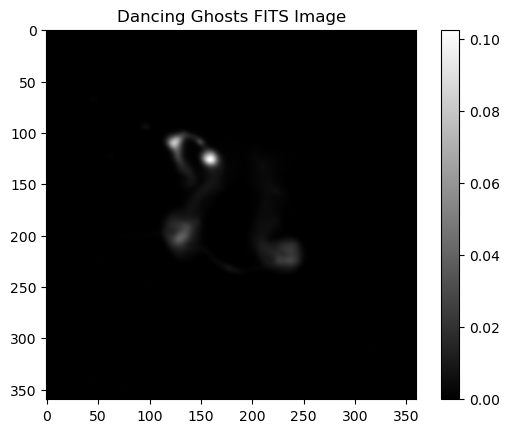

In [10]:


plt.imshow(image_data, cmap='gray')
plt.colorbar()
plt.title("Dancing Ghosts FITS Image")
plt.show()


<hr>
    Question 2e:<br>

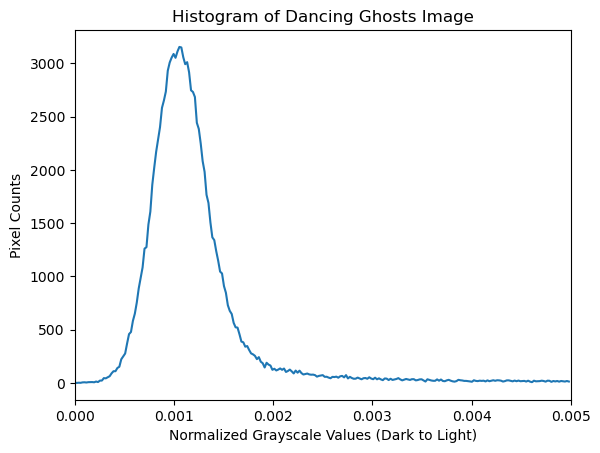

In [11]:
# normalize grayscale between 0 and 1
data = (image_data - np.min(image_data)) / np.max(image_data)

# bin range
xrange = [0, 0.005]

# binning
histogram, bin_edges = np.histogram(
    data,           # data to histogram
    bins=256,       # number of bins
    range=xrange    # grayscale range
)

# plotting
plt.plot(
    bin_edges[0:-1],   # x-values of bin edges (left edges)
    histogram          # counts per bin
)

plt.title("Histogram of Dancing Ghosts Image")
plt.xlabel("Normalized Grayscale Values (Dark to Light)")
plt.ylabel("Pixel Counts")
plt.xlim(xrange)
plt.show()


<hr>
    Question 2f:<br>

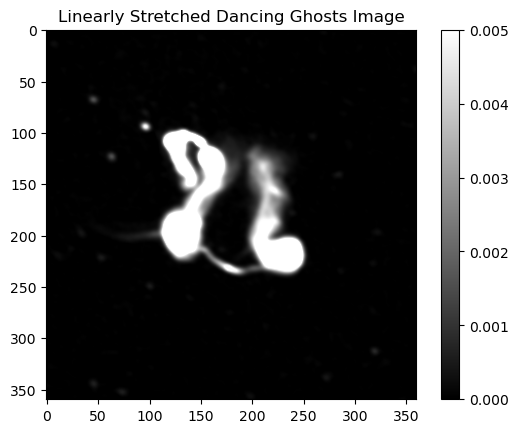

In [12]:


fig, ax = plt.subplots()
plt.imshow(image_data, cmap='gray', vmin=0.0, vmax=0.005)
plt.colorbar()
plt.title("Linearly Stretched Dancing Ghosts Image")
plt.show()


<hr>
    Question 3:<br>
    <i>Image Processing:</i>

<hr>
    Question 3a:<br>

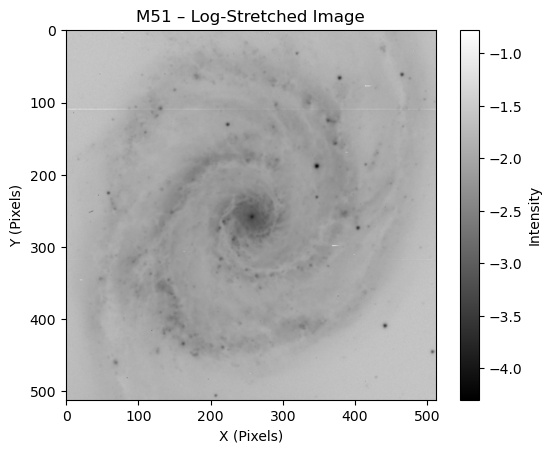

In [13]:

hdul = fits.open('M51.fits')
data_raw = hdul[0].data.copy()         
data_clean = clean(data_raw)
data = -np.log10(data_clean)

plt.imshow(data, cmap='gray')
plt.colorbar(label="Intensity")
plt.title("M51 – Log-Stretched Image")
plt.xlabel("X (Pixels)")
plt.ylabel("Y (Pixels)")
plt.show()


<hr>
    Question 3b:<br>

In [14]:

def convolve(image, kernal):
    conv = np.zeros(image.shape)
    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            for i in range(kernal.shape[0]):
                p = x - kernal.shape[0]//2 + i
                if 0 <= p < image.shape[0]:
                    for j in range(kernal.shape[1]):
                        q = y - kernal.shape[1]//2 + j
                        if 0 <= q < image.shape[1]:
                            conv[x, y] += kernal[i, j] * image[p, q]
    return conv


In [15]:

def mk_boxcar(n):
    """Return an n x n boxcar (mean) filter."""
    return np.ones((n, n)) / n**2

box3 = mk_boxcar(3)
box3


array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

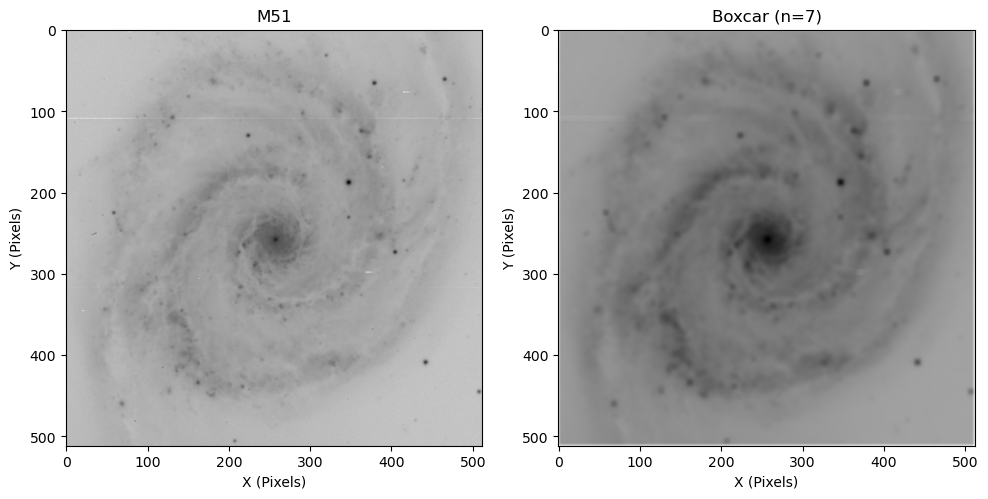

In [16]:


d_boxcar = convolve(data, mk_boxcar(7))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].set_title("M51")
ax[0].imshow(data, cmap='gray')
ax[0].set_xlabel("X (Pixels)")
ax[0].set_ylabel("Y (Pixels)")

ax[1].set_title("Boxcar (n=7)")
ax[1].imshow(d_boxcar, cmap='gray')
ax[1].set_xlabel("X (Pixels)")
ax[1].set_ylabel("Y (Pixels)")

plt.tight_layout()
plt.show()


<hr>
    Question 3c:<br>

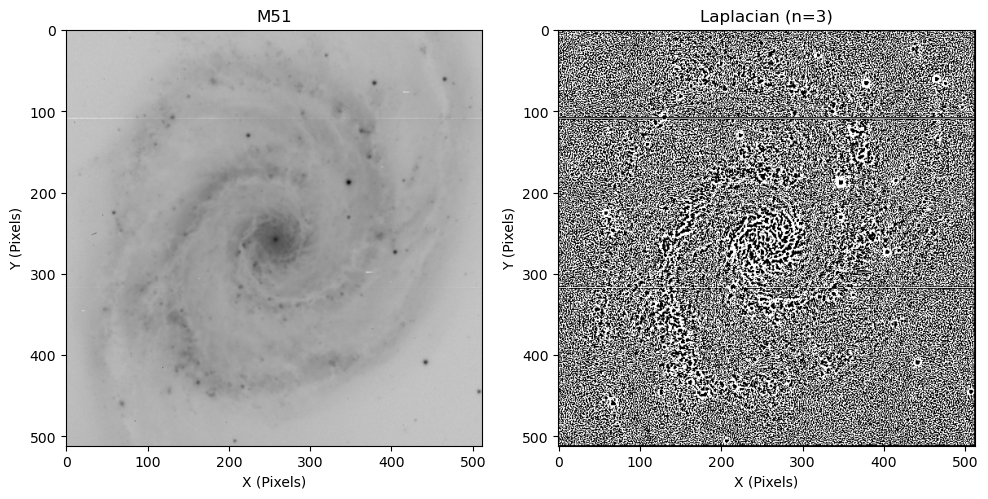

In [17]:
laplace = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
])

d_laplace = convolve(data, laplace)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].set_title("M51")
ax[0].imshow(data, cmap='gray')
ax[0].set_xlabel("X (Pixels)")
ax[0].set_ylabel("Y (Pixels)")

ax[1].set_title("Laplacian (n=3)")
ax[1].imshow(d_laplace, cmap='gray', vmin=-0.025, vmax=0.025)
ax[1].set_xlabel("X (Pixels)")
ax[1].set_ylabel("Y (Pixels)")

plt.tight_layout()
plt.show()


<hr>
    Question 3d:<br>

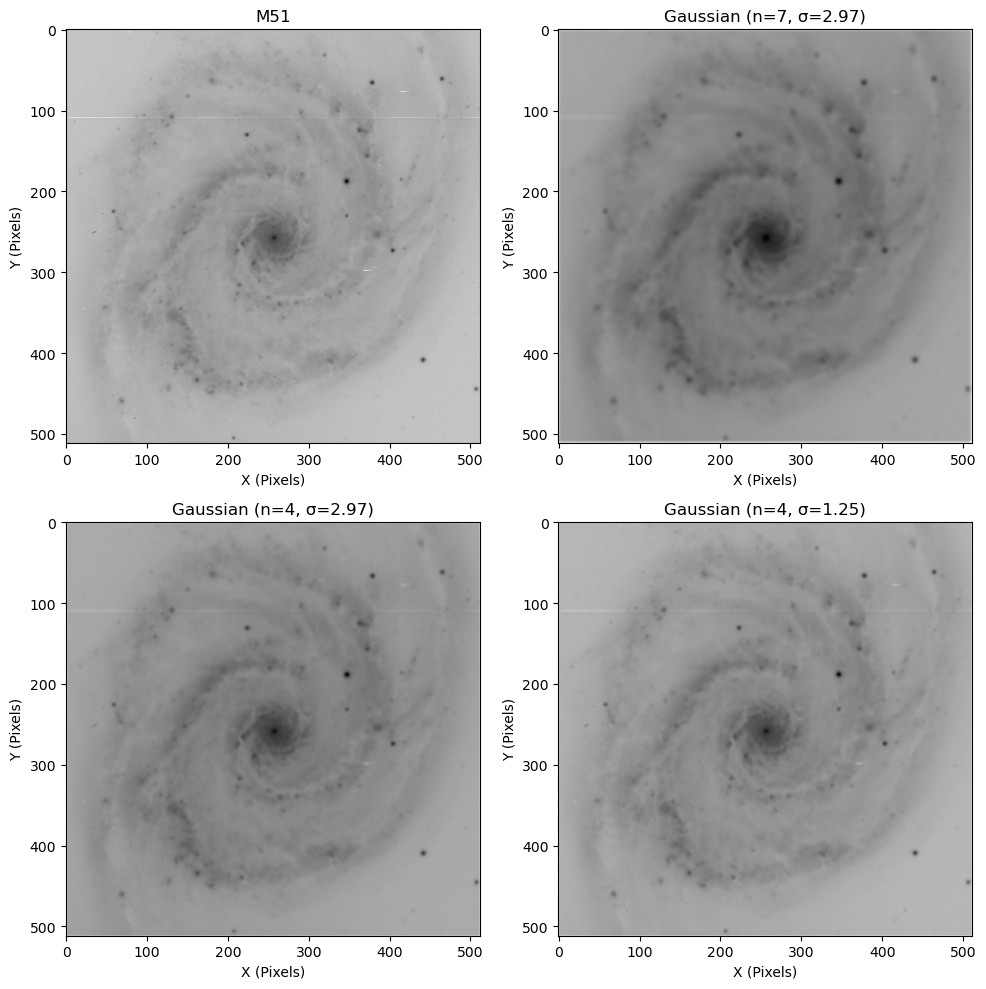

In [18]:

def mk_gaussian(n, sigma=1.25):
    def g(x, y, s):
        return np.exp(-(x**2 + y**2) / (2*s**2)) / (2 * np.pi * s**2)

    kernal = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            kernal[i, j] = g(i - n//2, j - n//2, sigma)
    return kernal / np.sum(kernal)

d_gauss_3 = convolve(data, mk_gaussian(3, sigma=1.25))
d_gauss_7 = convolve(data, mk_gaussian(7, sigma=2.97))

fig, ax = plt.subplots(2, 2, figsize=(10, 10))

ax[0, 0].set_title("M51")
ax[0, 0].imshow(data, cmap='gray')
ax[0, 0].set_xlabel("X (Pixels)")
ax[0, 0].set_ylabel("Y (Pixels)")

ax[0, 1].set_title("Gaussian (n=7, σ=2.97)")
ax[0, 1].imshow(d_gauss_7, cmap='gray')
ax[0, 1].set_xlabel("X (Pixels)")
ax[0, 1].set_ylabel("Y (Pixels)")

ax[1, 0].set_title("Gaussian (n=4, σ=2.97)")
ax[1, 0].imshow(convolve(data, mk_gaussian(4, sigma=2.97)), cmap='gray')
ax[1, 0].set_xlabel("X (Pixels)")
ax[1, 0].set_ylabel("Y (Pixels)")

ax[1, 1].set_title("Gaussian (n=4, σ=1.25)")
ax[1, 1].imshow(convolve(data, mk_gaussian(4, sigma=1.25)), cmap='gray')
ax[1, 1].set_xlabel("X (Pixels)")
ax[1, 1].set_ylabel("Y (Pixels)")

plt.tight_layout()
plt.show()


<hr>
    Question 3e:<br>

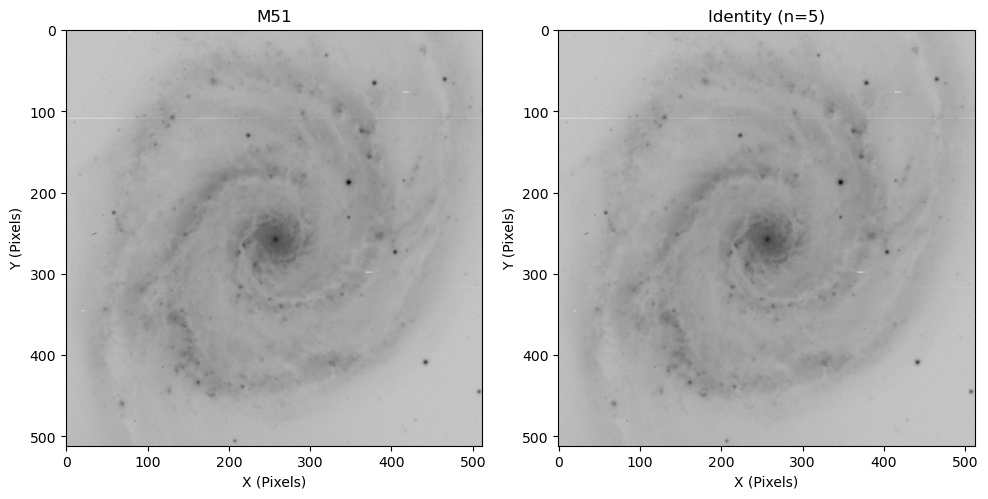

In [19]:

def mk_identity(n):
    """Return an n x n identity kernel (centre = 1, others = 0)."""
    kernal = np.zeros((n, n))
    center = n // 2
    kernal[center, center] = 1.0
    return kernal

d_identity = convolve(data, mk_identity(5))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].set_title("M51")
ax[0].imshow(data, cmap='gray')
ax[0].set_xlabel("X (Pixels)")
ax[0].set_ylabel("Y (Pixels)")

ax[1].set_title("Identity (n=5)")
ax[1].imshow(d_identity, cmap='gray')
ax[1].set_xlabel("X (Pixels)")
ax[1].set_ylabel("Y (Pixels)")

plt.tight_layout()
plt.show()


<hr>
    Question 3f:<br>

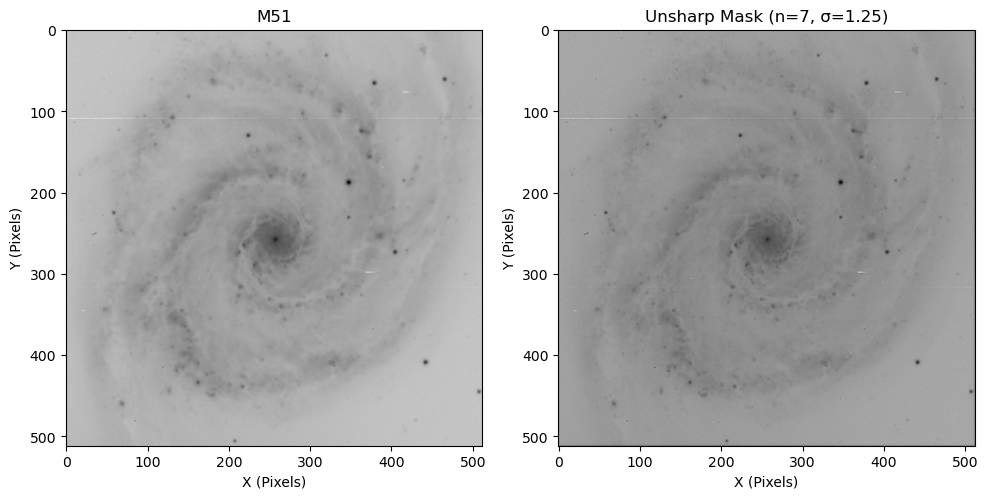

In [20]:

def mk_unsharp(n, sigma=1.25):
    """Unsharp mask kernel: 2I - G."""
    I = mk_identity(n)
    G = mk_gaussian(n, sigma=sigma)
    return 2*I - G

d_unsharp = convolve(data, mk_unsharp(7, sigma=1.25))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].set_title("M51")
ax[0].imshow(data, cmap='gray')
ax[0].set_xlabel("X (Pixels)")
ax[0].set_ylabel("Y (Pixels)")

ax[1].set_title("Unsharp Mask (n=7, σ=1.25)")
ax[1].imshow(d_unsharp, cmap='gray')
ax[1].set_xlabel("X (Pixels)")
ax[1].set_ylabel("Y (Pixels)")

plt.tight_layout()
plt.show()


<hr>
    Question 3g:<br>

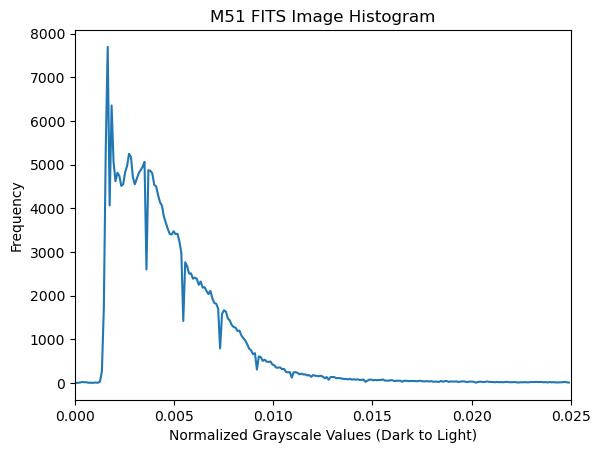

In [21]:

raw = clean(fits.open('M51.fits')[0].data.copy())
raw = (raw - np.min(raw)) / np.max(raw)

xrange = [0, 0.025]             
histogram, bin_edges = np.histogram(raw, bins=256, range=xrange)

plt.figure()
plt.plot(bin_edges[0:-1], histogram)
plt.title("M51 FITS Image Histogram")
plt.xlabel("Normalized Grayscale Values (Dark to Light)")
plt.ylabel("Frequency")
plt.xlim(xrange)
plt.show()
